## Phase 2 - Data Understanding

This is where we explore the data, relate it to the business problem, and surface actionable insights. 


In [1]:
# Libraries 

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load CSV file
# Create target variable

df = pd.read_csv("desafio_nps_fase_1.csv")

df["nps_detrator"] = (df['nps_score'] <= 6).astype(int)


## 1. Understanding the dataset structure

This is where we explore the data, relate it to the business problem, and surface actionable insights.  


In [3]:
# Understanding dataset structure

# How many rows and columns does the dataset have?
df.shape


(2500, 20)

The dataset has 2,500 rows and 20 columns


In [4]:
# First rows of the dataset
df.head()


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_detrator
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,0
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,1
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,1
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,1
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,0


We have important variables for logistics, customer service, orders, and region. 


In [5]:
# Data type of each variable
df.dtypes


customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
nps_detrator                   int64
dtype: object

Understanding each variable type and the kind of data we are working with.

- Numeric variables  




- Categorical variables  


In [6]:
# Does the dataset contain any null values?
df.isnull().sum()


customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
nps_detrator                 0
dtype: int64

This dataset has no null values in any column.


In [7]:
# Are there duplicate rows?
df.duplicated().sum()


np.int64(0)

We also have no duplicate rows.


## 2. Descriptive statistics

Descriptive statistics summarize the center and spread of each variable.


In [8]:
# Descriptive statistics

# Mean, median, standard deviation, min/max for all numeric variables
df.describe()


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_detrator
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600,0.740400
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957,0.438503
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000,0.000000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000,1.000000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000,1.000000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000,1.000000


**With `.describe()` we can go deeper into the data. Below is a readout by variable:**

customer_age: Mean age is 43, half of customers are that age or younger than that, the profile skews toward younger adults.

customer_tenure_months: The mean time on file is 61 months, so customers tend to stay with the company a long time.

delivery_time_days: Mean delivery time is about 8 days, about a quarter of customers see delivery between 11 and 14 days.

delivery_delay_days: Mean delay is about 2 days on affected deliveries, about a quarter of customers see delays between 3 and 8 days.

nps_score: Mean score is only 4.37—quite low. Three-quarters of customers score the company at 6.1 or below, in practice that aligns with a large share of detractor-level sentiment.


## 3. Analyzing the target

Highlighting class imbalance in the dataset. 


In [9]:
# 1. Absolute counts
counts = df['nps_detrator'].value_counts()

# 2. Percentages (normalize=True gives proportions; multiply by 100)
pct = df['nps_detrator'].value_counts(normalize=True) * 100

# 3. Combine into a summary table
nps_summary = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': pct
})

# Optional: format percentages to two decimal places
nps_summary['Percentage (%)'] = nps_summary['Percentage (%)'].map('{:.2f}%'.format)

print(nps_summary)


              Count Percentage (%)
nps_detrator                      
1              1851         74.04%
0               649         25.96%


The dataset is strongly skewed toward detractors, who make up about 74% of the base.

That imbalance matches Analytical Objective 1 and supports recall as the primary metric. For the business, it is usually cheaper to flag all likely detractors, even with false positives (customers who would not detract or are already satisfied) than to optimize precision and miss real detractors.

High recall → the model catches most detractors → the company can intervene early

High precision → the model is conservative → but some detractors may get no action



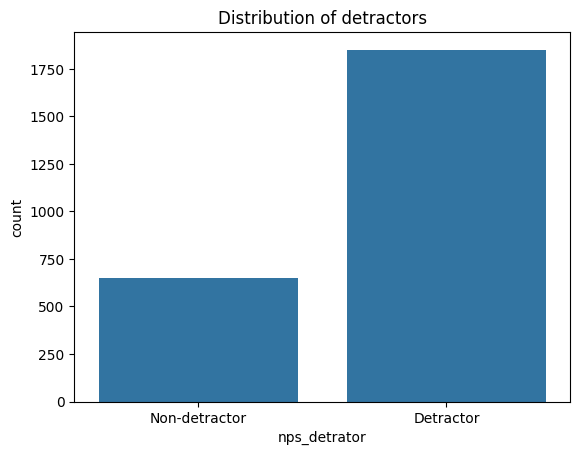

In [10]:
sns.countplot(data=df, x='nps_detrator')

plt.title('Distribution of detractors')

plt.xticks([0, 1], ['Non-detractor', 'Detractor']);


## 4. Variable distributions

We relate the variables below to NPS < 6.

**Logistics — did the customer get the order on time? How many delivery attempts were needed?**  
Logistics: delivery_delay_days, delivery_attempts, delivery_time_days    

**Customer service — did the customer contact support? Was the issue resolved quickly?**  
Customer service: customer_service_contacts, resolution_time_days, complaints_count      

**Order — do order value or freight affect perceived satisfaction?**    
Order: order_value, freight_value  


### Logistics group

We inspect logistics variables for patterns—for example, whether more delay days and more delivery attempts line up with being a detractor.


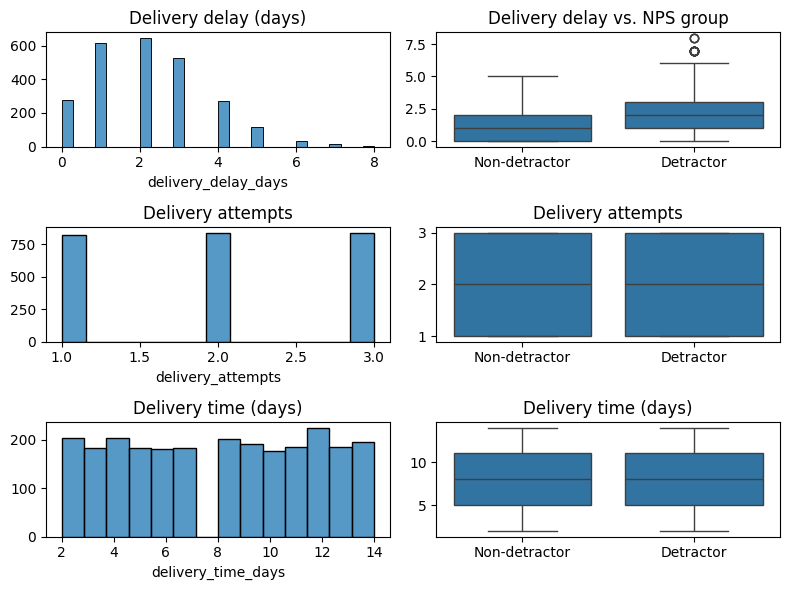

In [16]:

# Logistics group
fig, axes = plt.subplots(3, 2, figsize=(8, 6))

# Row 0 - delivery_delay_days
sns.histplot(data=df, x='delivery_delay_days', ax=axes[0, 0])
axes[0,0].set_title('Delivery delay (days)')
axes[0,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='delivery_delay_days', ax=axes[0, 1])
axes[0,1].set_title('Delivery delay vs. NPS group')
axes[0,1].set_ylabel('')
axes[0,1].set_xlabel('')
axes[0,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])

# Row 1 - delivery_attempts
sns.histplot(data=df, x='delivery_attempts', ax=axes[1, 0])
axes[1,0].set_title('Delivery attempts')
axes[1,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='delivery_attempts', ax=axes[1, 1])
axes[1,1].set_title('Delivery attempts')
axes[1,1].set_ylabel('')
axes[1,1].set_xlabel('')
axes[1,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])

# Row 2 - delivery_time_days
sns.histplot(data=df, x='delivery_time_days', ax=axes[2, 0])
axes[2,0].set_title('Delivery time (days)')
axes[2,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='delivery_time_days', ax=axes[2, 1])
axes[2,1].set_title('Delivery time (days)')
axes[2,1].set_ylabel('')
axes[2,1].set_xlabel('')
axes[2,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])

plt.tight_layout()
plt.ylabel('')
plt.show()



### Logistics variables — what we see

- delivery_delay_days

The distribution is right-skewed: most orders show 0–3 days of delay, but extreme cases reach 8 days. Long delays are uncommon but they exist.

In the boxplot, detractors have a clearly higher median than non-detractors. Outliers appear only among detractors (points above the box). Customers with more delay days are more likely to be detractors. In practice a typical non-detractor waited about 1 day past the promised date; a typical detractor about 2.

Delivery delay is associated with dissatisfaction.


- delivery_attempts

The boxplots look similar, no clear association.
The number of delivery attempts does not separate detractors from non-detractors and does not appear to drive satisfaction.


- delivery_time_days    

Again similar boxplots—no association.
Interestingly, there are no orders with exactly 7 days in the dataset.
Total delivery time does not drive satisfaction; what matters is delay relative to the promised date, not absolute transit time.


**Among the three logistics variables, only `delivery_delay_days` lines up with NPS. That is an important insight: the issue is not total delivery time but missing the promised window. Cutting delay from 2 days to 1 could be enough to keep some customers from becoming detractors.**



## Customer service group


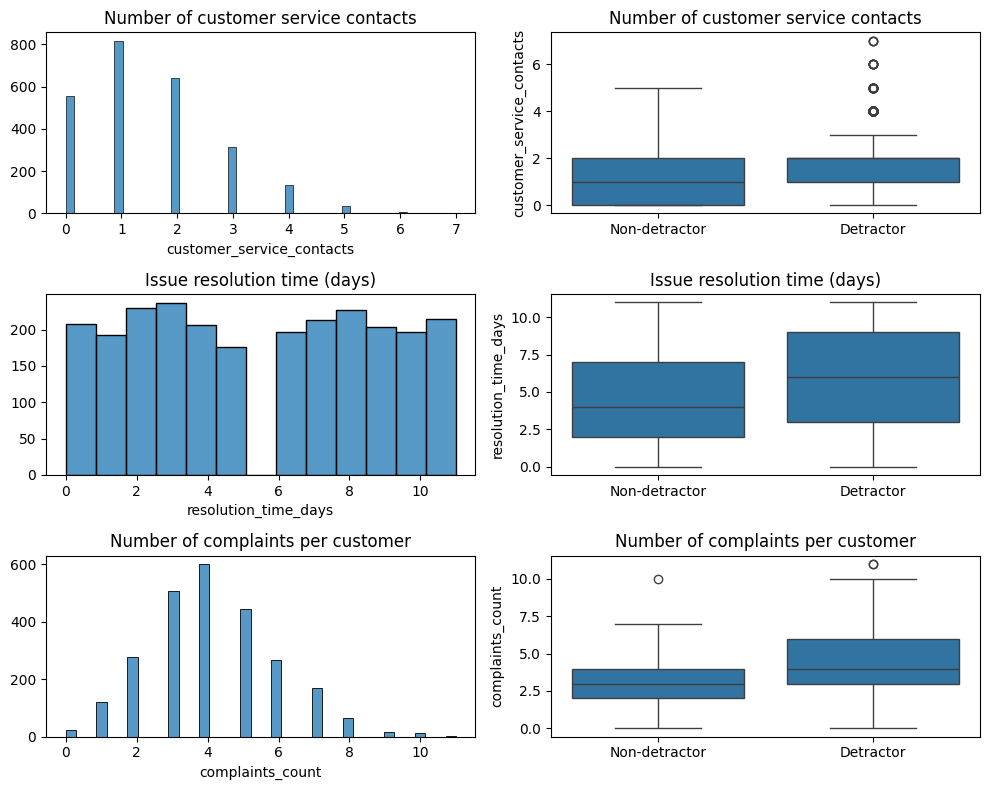

In [12]:
# Customer service group
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

# Row 0 - customer_service_contacts
sns.histplot(data=df, x='customer_service_contacts', ax=axes[0, 0])
axes[0,0].set_title('Number of customer service contacts')
axes[0,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='customer_service_contacts', ax=axes[0, 1])
axes[0,1].set_title('Number of customer service contacts')
axes[0,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])
axes[0,1].set_xlabel('')

# Row 1 - resolution_time_days
sns.histplot(data=df, x='resolution_time_days', ax=axes[1, 0])
axes[1,0].set_title('Issue resolution time (days)')
axes[1,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='resolution_time_days', ax=axes[1, 1])
axes[1,1].set_title('Issue resolution time (days)')
axes[1,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])
axes[1,1].set_xlabel('')

# Row 2 - complaints_count
sns.histplot(data=df, x='complaints_count', ax=axes[2, 0])
axes[2,0].set_title('Number of complaints per customer')
axes[2,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='complaints_count', ax=axes[2, 1])
axes[2,1].set_title('Number of complaints per customer')
axes[2,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])
axes[2,1].set_xlabel('')

plt.tight_layout()
plt.show()


### Customer service variables — what we see

- customer_service_contacts  

The histogram is right-skewed: most contacts happen on the same day through day 3.
The boxplots are similar, but detractors sit slightly higher.
Customers who contacted support more often are slightly more likely to be detractors, as suggested by the outliers.

- resolution_time_days

Detractors have a clearly higher median.
Customers who waited longer for issues to be resolved are more likely to be detractors. Resolution time is tied to dissatisfaction.


- complaints_count

The histogram is fairly symmetric with a peak around four complaints per customer.

In the boxplot, customers with more complaints are much more likely to be detractors. This is the customer-service signal that lines up most clearly with dissatisfaction.


**Among the three variables, `resolution_time_days` and `complaints_count` show a clear link to low NPS. That points to service quality as a satisfaction driver. Faster resolution and fewer complaints could keep some customers from becoming detractors.**


## Order group


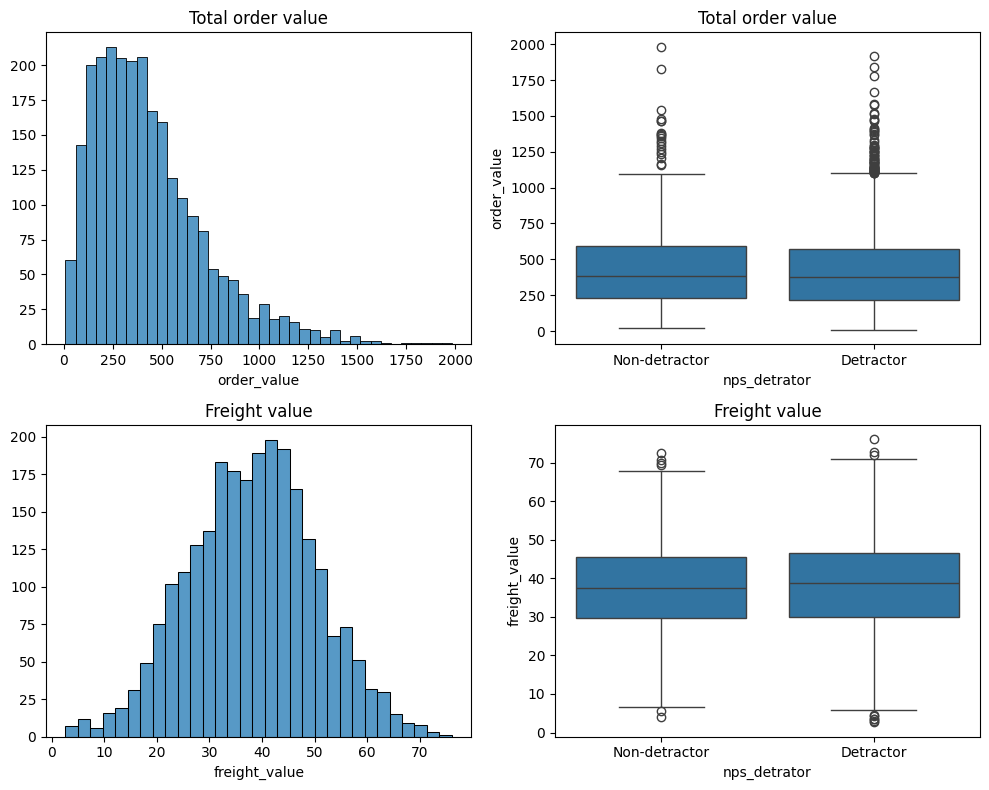

In [13]:
# Order group
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Row 0 - order_value
sns.histplot(data=df, x='order_value', ax=axes[0, 0])
axes[0,0].set_title('Total order value')
axes[0,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='order_value', ax=axes[0, 1])
axes[0,1].set_title('Total order value')
axes[0,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])

# Row 1 - freight_value
sns.histplot(data=df, x='freight_value', ax=axes[1, 0])
axes[1,0].set_title('Freight value')
axes[1,0].set_ylabel('')

sns.boxplot(data=df, x='nps_detrator', y='freight_value', ax=axes[1, 1])
axes[1,1].set_title('Freight value')
axes[1,1].set_xticks([0, 1], ['Non-detractor', 'Detractor'])

plt.tight_layout()
plt.show()


### Order variables — what we see

Neither order value nor freight value appears to drive satisfaction. Dissatisfaction is not about how much the customer spent, but about experience quality—delivery and service.


## Correlation between variables (heatmap)

The heatmap shows which variables move together and which move in opposite directions—for example, longer delivery delays and more customer contacts correlate with lower `nps_score`.

The variables `csat_internal_score` and `repeat_purchase_30d` were dropped because of leakage risk.

Note that we analyze the target `nps_detrator`, not `nps_score`.


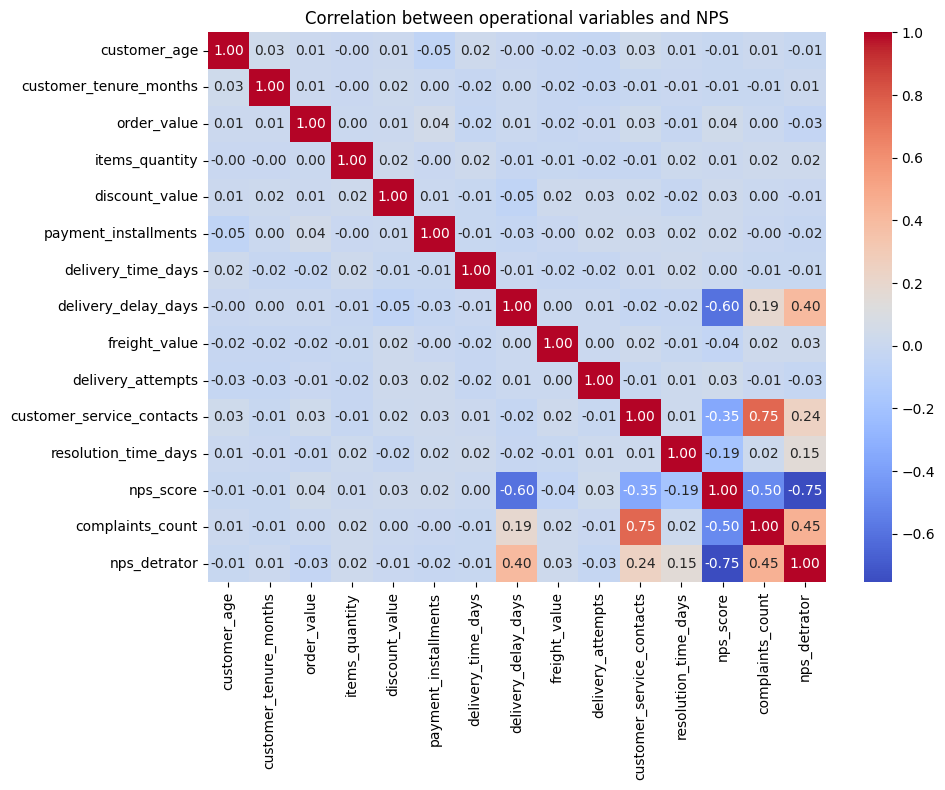

In [14]:
columns_to_drop = ['customer_id', 'order_id', 'csat_internal_score', 'repeat_purchase_30d']

correlation = df.drop(columns=columns_to_drop).corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between operational variables and NPS')
plt.tight_layout()
plt.show()


## 5. Interpreting the heatmap

### Strongest relationships
The variables most correlated with `nps_detrator` are `complaints_count` (0.45) and `delivery_delay_days` (0.40), matching the boxplot story. More complaints and more delay days align with being a detractor.

### Weaker relationships
`customer_service_contacts` (0.24) and `resolution_time_days` (0.15) show only weak correlation with the target.

### Inverse relationships
`nps_score` (-0.75) is negatively correlated: as `nps_score` rises, `nps_detrator` falls.  

`nps_detrator` = 1 when `nps_score` ≤ 6 → low score = detractor  
`nps_detrator` = 0 when `nps_score` > 6 → high score = non-detractor  

### Business takeaway
These results suggest the company should prioritize cutting complaints and hitting delivery promises as the main levers to improve satisfaction.

That answers Analytical Objective 1: the top three variables associated with NPS ≤ 6 are:  
- complaints_count
- delivery_delay_days
- resolution_time_days


## 6. Analysis by region

We check whether detractor rate differs across Brazilian regions—directly tied to regional-bias risk in Analytical Objective 1 (diagnostic analysis).


In [15]:
df.groupby('customer_region')['nps_detrator'].mean()

customer_region
Centro-Oeste    0.743590
Nordeste        0.740206
Norte           0.745059
Sudeste         0.746154
Sul             0.727447
Name: nps_detrator, dtype: float64

The gap between the highest detractor rate, Southeast (74.6%), and the lowest, South (72.7%), is only 1.9 percentage points.  

**What does that mean for the business?**  
There does not appear to be meaningful regional bias; all regions are close in percentage terms.


## 7. Summary of insights


The exploratory analysis showed the variables most associated with customer dissatisfaction were:

### Customer service
- complaints_count (0.45)

### Logistics
- delivery_delay_days (0.40)



`customer_service_contacts` (0.24) and `resolution_time_days` (0.15) correlate weakly with the target, and `delivery_attempts` (-0.03) shows no meaningful link to satisfaction.  

The regional check showed no regional bias.

The focus should therefore be on service—hearing complaints and resolving them as fast as possible—and on logistics—keeping delays as low as possible. 




Next, in the Data Preparation phase, low-value variables and leakage-prone ones (`csat_internal_score`, `repeat_purchase_30d`) will be removed. `complaints_count` and `delivery_delay_days` will be prioritized as predictive features.
